### Dataset Description:

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Attribute Information:

- age

- sex

- chest pain type (4 values)

- resting blood pressure

- serum cholestoral in mg/dl

- fasting blood sugar > 120 mg/dl

- resting electrocardiographic results (values 0,1,2)

- maximum heart rate achieved

- exercise induced angina

- oldpeak = ST depression induced by exercise relative to rest

- the slope of the peak exercise ST segment

- number of major vessels (0-3) colored by flourosopy

- thal: 3 = normal; 6 = fixed defect; 7 = reversable defect

- target:0 for no presence of heart disease, 1 for presence of heart disease

#### 1) Importing Necessary Libraries:

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, RocCurveDisplay, roc_curve, roc_auc_score, auc, confusion_matrix

from sklearn.pipeline import Pipeline

#### 2) Loading Data:

In [3]:
df = pd.read_csv('heart.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.shape

(303, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


#### 3) Data Exploration and Transformations:

In [9]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

- Target Variable is Balanced.

<Figure size 800x600 with 0 Axes>

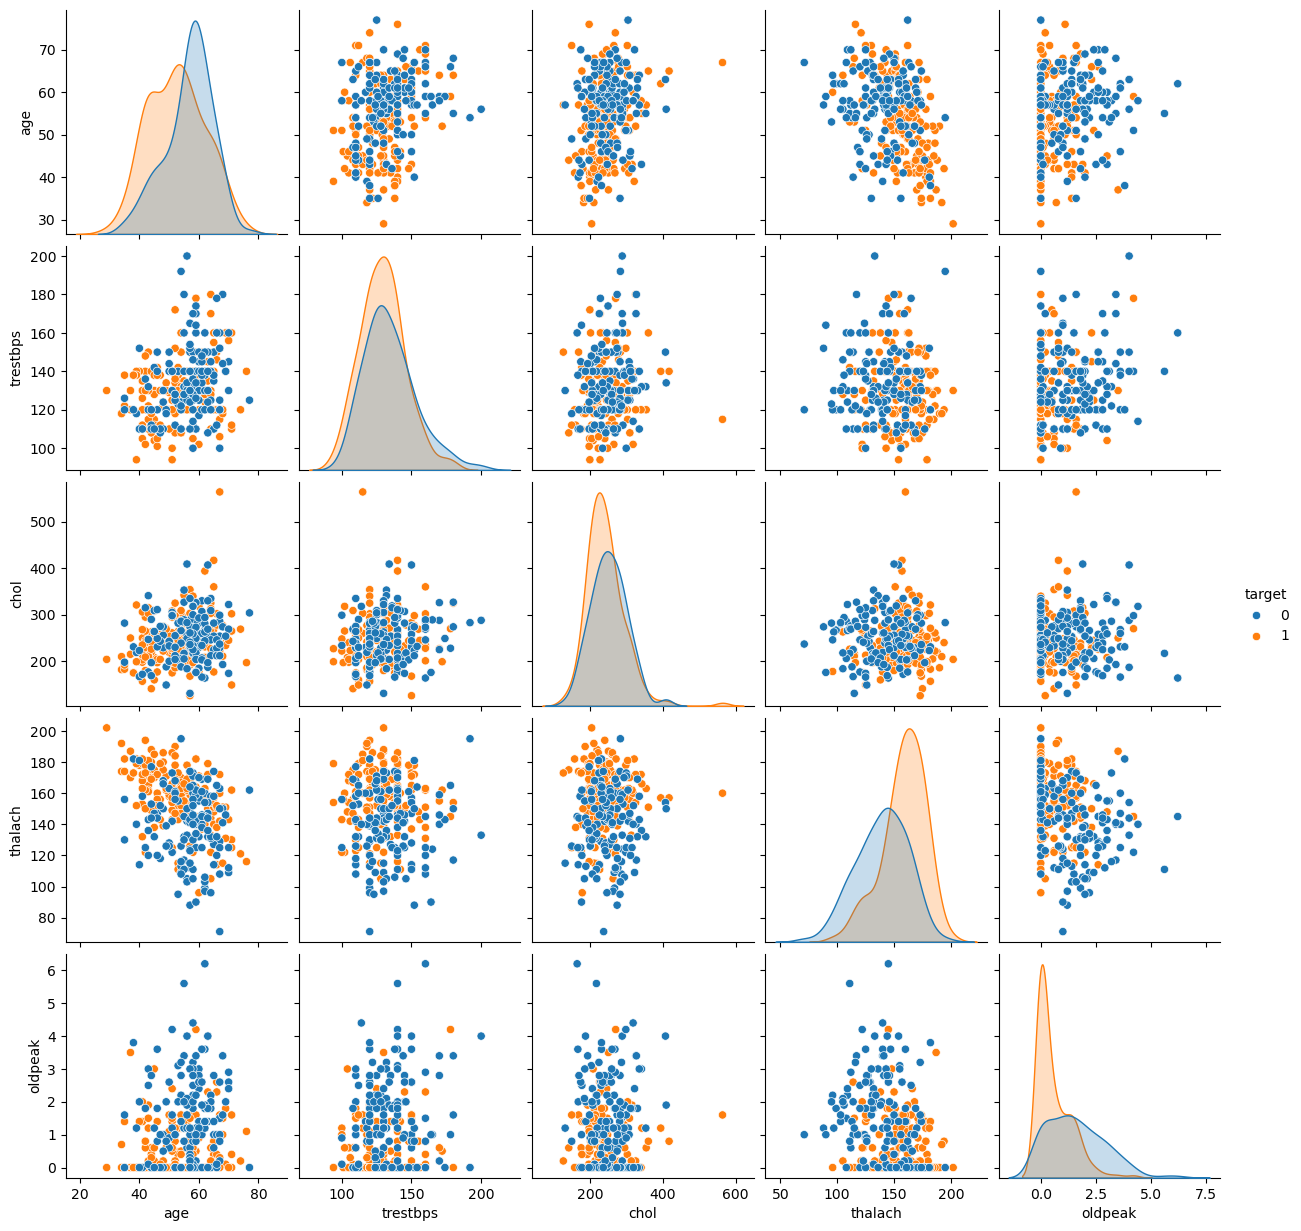

In [10]:
# Relationship Between Continuous Variables:

plt.figure(figsize= (8,6))
sns.pairplot(data= df[["age","trestbps","chol","thalach","oldpeak","target"]], hue= 'target')
plt.show()

- There's no Visually Clear Realtionship Between any Continuous Variables.

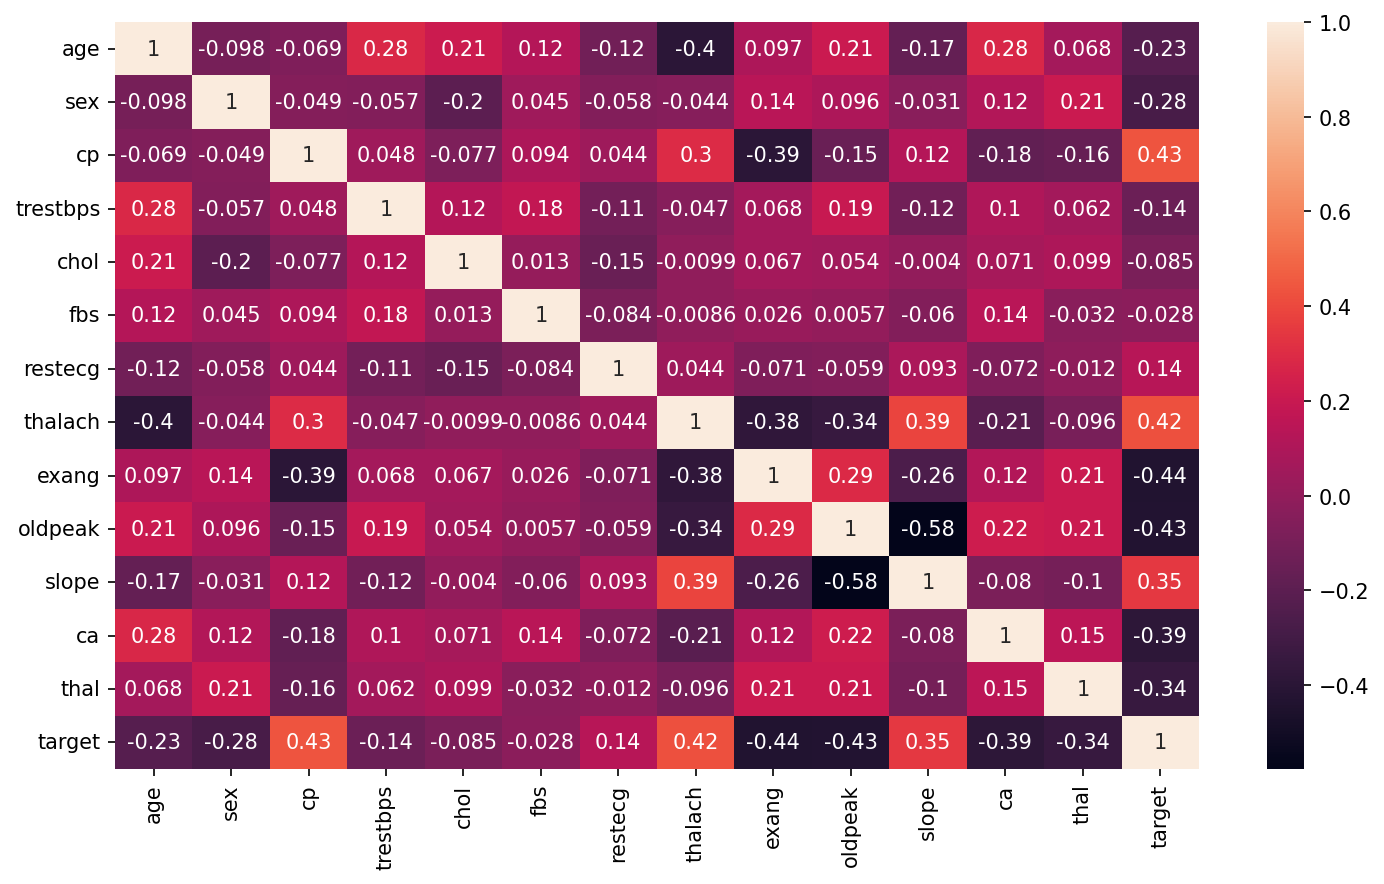

In [11]:
# Correlation Between Features and Target:

plt.figure(figsize=(10,6), dpi= 150)

sns.heatmap(data= df.corr(), annot= True)

plt.tight_layout()

plt.show()

- No Features have Really High or Really Low Positive or Negative Correlation with Target.
- Some Moderate Positive and Negative Correlation with Target can be seen (CP, THALACH, EXANG, OLDPEAK, CA, THAL).

- There are Numeric and Categorical Features present in Data.
- Categoric Features are already Encoded Ordinally.
- Numeric Features seems mostly Normally distributed.
- Scaling for Numeric Features is required.
- Encoding for Nominal Categorical Features like 'cp', 'restecg', 'thal' is required.

In [39]:
ct = ColumnTransformer([
    ('scaler', StandardScaler(), ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']),
    ('encoder', OneHotEncoder(), ['cp', 'restecg', 'thal'])
])

#### 4) Train Test Split:

In [40]:
X = df.drop('target', axis= 1) # Features
y = df['target'] # Target

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 13)
(61, 13)
(242,)
(61,)


#### 5) Model Building and Evaluation:

In [46]:
logisitc_cv_model = LogisticRegressionCV(Cs= 20, cv= 10, penalty= "elasticnet", solver= "saga", max_iter= 10000,
                                  l1_ratios= [0, 0.01, 0.1, 0.5, 0.75, 0.9, 0.99, 1])

In [47]:
model_pipeline = Pipeline([
    ('preprocessing', ct),
    ('model', logisitc_cv_model)
])

In [48]:
model_pipeline.fit(X_train, y_train) # Model Fitting

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
# Predictions Using Model:
y_pred = model_pipeline.predict(X_test)

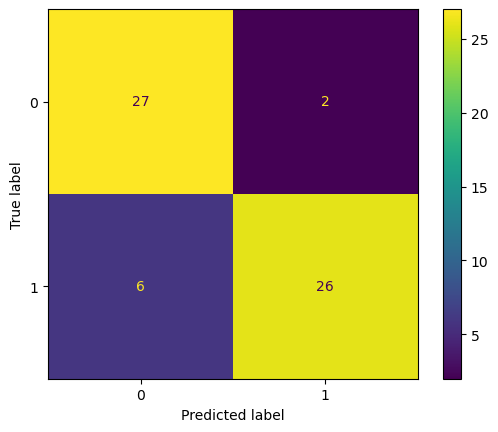

In [50]:
# Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= model_pipeline.classes_)
disp.plot()
plt.show()

In [51]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87        29
           1       0.93      0.81      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



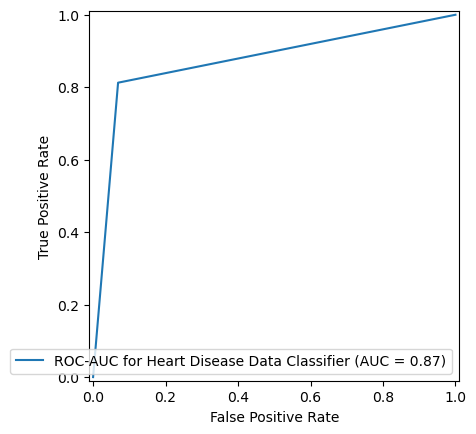

In [52]:
# ROC-AUC Curve:

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
disp = RocCurveDisplay(fpr= fpr, tpr= tpr, roc_auc= roc_auc, name= 'ROC-AUC for Heart Disease Data Classifier')
disp.plot()
plt.show()